In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv


Sometimes data is numerical but too spread, like:
Apps Downloads: 12,42,6543234567,43,45332,5345653456,53325
now using this wide ranged and high standard deviation data affects the results sometimes and outliers can be missed.
Now this type of data will require to be encoded in categorical data. Some categories may be:
1+, 10+, 100+, 1k+, 10k+, 100k+, 1M+,10M+ etc (now it's very easy to analyse the data)

For this type of encoding two techniques are used:
1. Discretization (Binning)
2. Binarization

Some techniques to implement Binning (Discretization) are below:
1. Unsupervised Binning
   >Equal Width (uniform); 
   >Equal Frequency (Quantile) &
   >K means

2. Supervised Binning
   >Decision Tree Binning
    
3. Custom Binning

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/adult-census-income")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/uciml/adult-census-income


# Discretization

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split ,cross_val_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn import set_config

set_config(transform_output= 'pandas')

In [4]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv", usecols=['age','fnlwgt','income'])
df.sample(3)

,age,fnlwgt,income
16004,54,159755,>50K
2236,65,139960,>50K
25828,40,111483,<=50K


In [5]:
df.describe()

,age,fnlwgt
count,32561.000000,3.256100e+04
mean,38.581647,1.897784e+05
std,13.640433,1.055500e+05
min,17.000000,1.228500e+04
25%,28.000000,1.178270e+05
50%,37.000000,1.783560e+05
75%,48.000000,2.370510e+05
max,90.000000,1.484705e+06


In [6]:
X=df.iloc[:,0:-1]
y= df.iloc[:,-1]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state =42)

In [8]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [9]:
predicted_y = clf.predict(X_train)
accuracy_score(predicted_y , y_train)
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=8,scoring='accuracy'))

np.float64(0.6875099885508876)

# Binning to Encode fnlwgt Feature

In [10]:
 from sklearn.preprocessing import KBinsDiscretizer


In [11]:
fnlwgt_disc = KBinsDiscretizer (n_bins=1473, encode='ordinal', strategy='uniform') # 1473 n_bins to represent 12285 - 1484705 data with each almost bin=1000

In [12]:
fnlwgt_disc.fit_transform(X_train)

,age,fnlwgt
5514,181.0,249.0
19777,141.0,161.0
10781,383.0,64.0
32240,100.0,12.0
9876,282.0,351.0
...,...,...
29802,161.0,406.0
5390,686.0,137.0
860,766.0,230.0
15795,484.0,144.0


In [13]:
fnlwgt_disc.transform (X_test)

,age,fnlwgt
14160,242.0,273.0
27048,40.0,436.0
28868,221.0,196.0
5667,363.0,97.0
7827,60.0,42.0
...,...,...
1338,201.0,141.0
24534,928.0,178.0
18080,786.0,99.0
10354,100.0,174.0


In [14]:
fnlwgt_disc.bin_edges_

array([array([17.        , 17.04955872, 17.09911745, ..., 89.90088255,
              89.95044128, 90.        ])                              ,
       array([  12285.        ,   13264.73523422,   14244.47046843, ...,
              1453475.52953157, 1454455.26476578, 1455435.        ])    ],
      dtype=object)

In [15]:
# but since i do not want to apply the discretization to both features, just on fnlwgt feature so two possible ways to achieve this:
#1. fit this discretization on only this column not whole X_train and then combine it with other column to achive the  transformed df or X_train
#2. use a ColumnTransformer and set [1] in it to tell on which column it should be applied, other column will be same ie. without any change

In [16]:
from sklearn.compose import ColumnTransformer

In [17]:
trf = ColumnTransformer([('fnlwgt_disc',KBinsDiscretizer (n_bins=1473, encode='ordinal', strategy='uniform'), [1] )]
                      , remainder= 'passthrough')

In [18]:
discretized_X_train= trf.fit_transform(X_train,y_train)
discretized_X_train

,fnlwgt_disc__fnlwgt,remainder__age
5514,249.0,26
19777,161.0,24
10781,64.0,36
32240,12.0,22
9876,351.0,31
...,...,...
29802,406.0,25
5390,137.0,51
860,230.0,55
15795,144.0,41


In [19]:
discretized_X_test = trf.transform(X_test)

In [20]:
trf['fnlwgt_disc'].bin_edges_

array([array([  12285.        ,   13264.73523422,   14244.47046843, ...,
              1453475.52953157, 1454455.26476578, 1455435.        ])    ],
      dtype=object)

In [21]:
output = pd.DataFrame({
    'age': X_train['age'],
    'fnlwgt' : X_train['fnlwgt'],
    'binned_fnlwgt': discretized_X_train.iloc[:, -1]
 })

In [22]:
trf.named_transformers_['fnlwgt_disc'].bin_edges_[0].tolist()

[12285.0,
 13264.735234215887,
 14244.470468431771,
 15224.205702647658,
 16203.940936863544,
 17183.67617107943,
 18163.411405295315,
 19143.1466395112,
 20122.88187372709,
 21102.617107942973,
 22082.35234215886,
 23062.087576374746,
 24041.82281059063,
 25021.558044806516,
 26001.293279022404,
 26981.02851323829,
 27960.763747454177,
 28940.49898167006,
 29920.234215885946,
 30899.969450101835,
 31879.70468431772,
 32859.43991853361,
 33839.17515274949,
 34818.91038696538,
 35798.64562118126,
 36778.38085539715,
 37758.11608961303,
 38737.851323828916,
 39717.58655804481,
 40697.32179226069,
 41677.05702647658,
 42656.79226069247,
 43636.527494908354,
 44616.26272912424,
 45595.99796334012,
 46575.73319755601,
 47555.46843177189,
 48535.20366598778,
 49514.93890020367,
 50494.674134419554,
 51474.40936863544,
 52454.144602851324,
 53433.87983706721,
 54413.61507128309,
 55393.350305498985,
 56373.08553971487,
 57352.820773930755,
 58332.55600814664,
 59312.291242362524,
 60292.02647

In [23]:
output['fnlwgt_labels'] = pd.cut(x = X_train ['fnlwgt'],
                                bins=trf.named_transformers_['fnlwgt_disc'].bin_edges_[0].tolist())

In [24]:
output

,age,fnlwgt,binned_fnlwgt,fnlwgt_labels
5514,26,256263,26,"(256239.073, 257218.809]"
19777,24,170277,24,"(170022.373, 171002.108]"
10781,36,75826,36,"(74988.055, 75967.79]"
32240,22,24395,22,"(24041.823, 25021.558]"
9876,31,356689,31,"(356172.067, 357151.802]"
...,...,...,...,...
29802,25,410240,25,"(410057.505, 411037.24]"
5390,51,146767,51,"(146508.727, 147488.462]"
860,55,238192,55,"(237624.104, 238603.839]"
15795,41,154076,41,"(153366.874, 154346.609]"


In [25]:
clf.fit(discretized_X_train, y_train)

DecisionTreeClassifier()

In [26]:
predicted_y = clf.predict(discretized_X_test)

In [27]:
accuracy_score(predicted_y, y_test)

0.7067403654230001

In [28]:
 trf.fit(X, y)
discretized_X =trf.transform(X)

In [29]:
np.mean(cross_val_score(DecisionTreeClassifier(), discretized_X ,y, cv=9, scoring='accuracy' ))

np.float64(0.7083320448787374)

**cross_val_score improved from 0.6867729330791232 to 0.7086391937750297 after discretization**


**Python Function for Binning (you can use any of three unsupervised binning)**

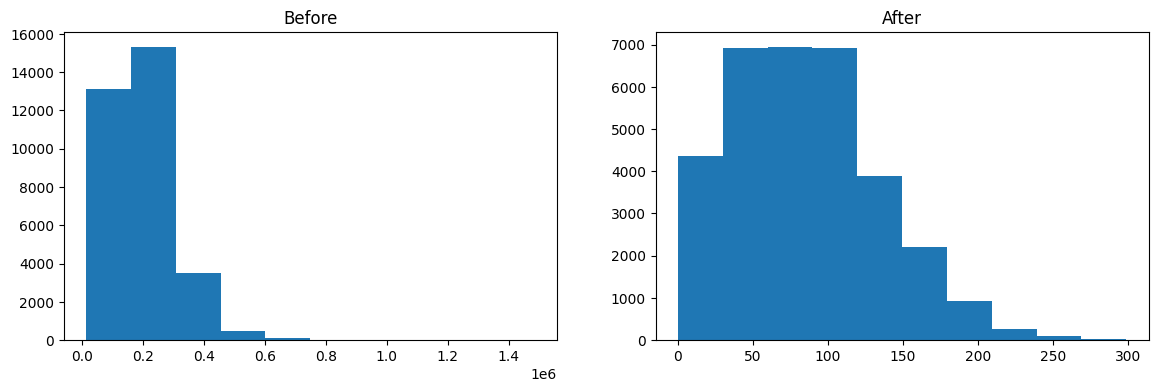

np.float64(0.7176999010562547)

In [30]:


def plotFigureWith2Histograms(series1, title1, series2, title2):

    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    plt.hist(series1)
    plt.title(title1)

    plt.subplot(122)
    plt.hist(series2)
    plt.title(title2)

    plt.show()


def predictByDiscretization (no_of_bins ,encoding_technique, disc_strategy):

    df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv" , usecols=['age', 'fnlwgt' , 'income'])

    #print(df.sample(4))

    X= df.iloc[:,0:-1]
    y= df.iloc[:,-1]

    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state = 42)
    
    trf= ColumnTransformer([('fnlwgt_trf', KBinsDiscretizer(n_bins=no_of_bins, encode=encoding_technique, strategy=disc_strategy), [1])],
                     remainder='passthrough')

    #print(trf)

    transformed_X_train = trf.fit_transform (X_train)
    transformed_X_test = trf.transform(X_test)

    clf = DecisionTreeClassifier()

    clf.fit(transformed_X_train, y_train)

    predicted_y = clf.predict(transformed_X_test)

    accuracyScore = accuracy_score(predicted_y, y_test)

    transformed_X = trf.fit_transform(X,y)

    #print(X)
    plotFigureWith2Histograms (X['fnlwgt'], "Before", transformed_X['fnlwgt_trf__fnlwgt'], "After")
    
    return np.mean(cross_val_score(DecisionTreeClassifier(),transformed_X,y, cv=20, scoring ='accuracy' ))



predictByDiscretization(300,'ordinal' ,'kmeans')

# Binarization

just encoding numerical data into binary values ie. 0 or 1 on the basis of some threshold, 
* like age above 18 and below 18. above 18 should have a feature isAdult with value 1 and below 18 should have 0. OR above 18 should have value 1 and below 18 should value 0 in age column.
* like we have a photo with its pixel grid. and we want to analyse it in black and white only. so we cahnge its pixel value (ranging from 0 to 255) into 0 or 1 on basis of 127. pixel value above 127 will encode into 1 and below 127 will be encoded into 0.

some times such type of encoding is needed based on data (what type of data it is)

In [31]:
from sklearn.preprocessing import Binarizer

In [32]:
trf = ColumnTransformer([('binazer', Binarizer(threshold=18, copy=False), [-1])],
                       remainder='passthrough')

In [33]:
df['isAdult']=df['age']
df

,age,fnlwgt,income,isAdult
0,90,77053,<=50K,90
1,82,132870,<=50K,82
2,66,186061,<=50K,66
3,54,140359,<=50K,54
4,41,264663,<=50K,41
...,...,...,...,...
32556,22,310152,<=50K,22
32557,27,257302,<=50K,27
32558,40,154374,>50K,40
32559,58,151910,<=50K,58


In [34]:
X= df.drop(columns=['income'], inplace=False)
y = df.iloc[:, 2]

In [35]:
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [36]:
trf.fit_transform(X_train, y_train)

,binazer__isAdult,remainder__age,remainder__fnlwgt
19749,1,58,290661
1216,1,62,109463
27962,1,33,137088
23077,1,24,117767
10180,1,67,431426
...,...,...,...
29802,1,25,410240
5390,1,51,146767
860,1,55,238192
15795,1,41,154076


In [37]:
trf.transform(X_test)

,binazer__isAdult,remainder__age,remainder__fnlwgt
14160,1,29,280618
27048,1,19,439779
28868,1,28,204734
5667,1,35,107991
7827,1,20,54152
...,...,...,...
32476,1,58,181974
21100,1,55,98361
27131,1,35,154410
25526,1,60,232337


In [38]:
df

,age,fnlwgt,income,isAdult
0,90,77053,<=50K,90
1,82,132870,<=50K,82
2,66,186061,<=50K,66
3,54,140359,<=50K,54
4,41,264663,<=50K,41
...,...,...,...,...
32556,22,310152,<=50K,22
32557,27,257302,<=50K,27
32558,40,154374,>50K,40
32559,58,151910,<=50K,58
